In [8]:
import kagglehub

path = kagglehub.dataset_download("marslinoedward/sms-spam-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-dataset


In [2]:
!pip install wordcloud

In [3]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter

from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

!pip install "transformers==4.49.0" tf-keras tensorflow
!pip install tensorflow
import tensorflow
import keras
from keras.models import Sequential
from keras.initializers import Constant
from keras.layers import (LSTM,
                          Embedding,
                          BatchNormalization,
                          Dense,
                          TimeDistributed,
                          Dropout,
                          Bidirectional,
                          Flatten,
                          GlobalMaxPool1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

from tqdm import tqdm
import os
import nltk
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch

from collections import defaultdict
from collections import Counter


from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    accuracy_score
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the

In [9]:
df = pd.read_csv("/kaggle/input/sms-spam-dataset/spam.csv", encoding="latin-1")
df = df.drop("Unnamed: 0", axis=1)
df.head()

,spamORham,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df['Message_len'] = df['Message'].apply(lambda x: len(x.split(' ')))
df.head()

,spamORham,Message,Message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [11]:
max(df['Message_len'])

171

In [12]:
balance_counts = df.groupby('spamORham')['spamORham'].agg('count').values
balance_counts

array([4825,  747])

In [13]:
primary_blue = "#496595"
primary_blue2 = "#85a1c1"
primary_blue3 = "#3f4d63"
primary_grey = "#c6ccd8"
primary_black = "#202022"
primary_bgcolor = "#f4f0ea"

primary_green = px.colors.qualitative.Plotly[2]

In [14]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=['ham'],
    y=[balance_counts[0]],
    name='ham',
    text=[balance_counts[0]],
    textposition='auto',
    marker_color=primary_blue
))
fig.add_trace(go.Bar(
    x=['spam'],
    y=[balance_counts[1]],
    name='spam',
    text=[balance_counts[1]],
    textposition='auto',
    marker_color=primary_grey
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Dataset distribution by target</span>'
)
fig.show()

In [15]:
ham_df = df[df['spamORham'] == 'ham']['Message_len'].value_counts().sort_index()
spam_df = df[df['spamORham'] == 'spam']['Message_len'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ham_df.index,
    y=ham_df.values,
    name='ham',
    fill='tozeroy',
    marker_color=primary_blue,
))
fig.add_trace(go.Scatter(
    x=spam_df.index,
    y=spam_df.values,
    name='spam',
    fill='tozeroy',
    marker_color=primary_grey,
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Data Roles in Different Fields</span>'
)
fig.update_xaxes(range=[0, 70])
fig.show()


In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:4: SyntaxWarning:

invalid escape sequence '\S'

<>:8: SyntaxWarning:

invalid escape sequence '\w'

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:4: SyntaxWarning:

invalid escape sequence '\S'

<>:8: SyntaxWarning:

invalid escape sequence '\w'

/tmp/ipykernel_497/2282808393.py:3: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_497/2282808393.py:4: SyntaxWarning:

invalid escape sequence '\S'

/tmp/ipykernel_497/2282808393.py:8: SyntaxWarning:

invalid escape sequence '\w'



In [17]:
df['message_clean'] = df['Message'].apply(clean_text)
df.head()

,spamORham,Message,Message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah i dont think he goes to usf he lives aroun...


In [18]:
stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

,spamORham,Message,Message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goes usf lives around though


In [19]:
stemmer = nltk.SnowballStemmer("english")

def stemm_text(text):
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text

In [20]:
df['message_clean'] = df['message_clean'].apply(stemm_text)
df.head()

,spamORham,Message,Message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goe usf live around though


In [21]:
def preprocess_data(text):
    text = clean_text(text)
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))

    return text

In [22]:
df['message_clean'] = df['message_clean'].apply(preprocess_data)
df.head()

,spamORham,Message,Message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say ear hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goe usf live around though


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['spamORham'])

LabelEncoder()

In [24]:
df['target_encoded'] = le.transform(df['spamORham'])
df.head()

,spamORham,Message,Message_len,message_clean,target_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...,0
1,ham,Ok lar... Joking wif u oni...,6,ok lar joke wif oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts m...,1
3,ham,U dun say so early hor... U c already then say...,11,dun say ear hor alreadi say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goe usf live around though,0


In [25]:
x = df['message_clean']
y = df['target_encoded']

print(len(x), len(y))

5572 5572


In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))

4179 4179
1393 1393


In [27]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(x_train)

CountVectorizer()

In [28]:
x_train_dtm = vect.transform(x_train)
x_test_dtm = vect.transform(x_test)

In [29]:
vect_tunned = CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=0.1, max_df=0.7, max_features=100)

In [30]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()

tfidf_transformer.fit(x_train_dtm)
x_train_tfidf = tfidf_transformer.transform(x_train_dtm)

x_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32170 stored elements and shape (4179, 5679)>

In [31]:
texts = df['message_clean']
target = df['target_encoded']

In [32]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(texts)

vocab_length = len(word_tokenizer.word_index) + 1
vocab_length
sequences = word_tokenizer.texts_to_sequences(texts)

In [33]:
import tensorflow as tf

In [34]:
sequences = [[1], [2, 3], [4, 5, 6]]
tf.keras.preprocessing.sequence.pad_sequences(
    sequences
    , maxlen=None, dtype='int32', padding='pre',
    truncating='pre', value=0.0
)


array([[0, 0, 1],
       [0, 2, 3],
       [4, 5, 6]], dtype=int32)

In [35]:
sequence = [[1], [2, 3], [4, 5, 6]]
tf.keras.preprocessing.sequence.pad_sequences(sequence, padding='post')

array([[1, 0, 0],
       [2, 3, 0],
       [4, 5, 6]], dtype=int32)

In [36]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [37]:
def embed(corpus):
    return word_tokenizer.texts_to_sequences(corpus)

longest_train = max(texts, key=lambda sentence: len(word_tokenize(sentence)))
length_long_sentence = len(word_tokenize(longest_train))

train_padded_sentences = pad_sequences(
    embed(texts),
    length_long_sentence,
    padding='post'
)

train_padded_sentences

array([[   2, 3179,  274, ...,    0,    0,    0],
       [   8,  236,  527, ...,    0,    0,    0],
       [   9,  356,  588, ...,    0,    0,    0],
       ...,
       [6728, 1002, 6729, ...,    0,    0,    0],
       [ 138, 1251, 1603, ...,    0,    0,    0],
       [1986,  378,  170, ...,    0,    0,    0]], dtype=int32)

In [40]:
import kagglehub

path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'glove6b100dtxt' dataset.
Path to dataset files: /kaggle/input/glove6b100dtxt


In [41]:
embeddings_dictionary = dict()
embedding_dim = 100

with open('/kaggle/input/glove6b100dtxt/glove.6B.100d.txt') as fp:
    for line in fp.readlines():
        records = line.split()
        word = records[0]
        vector_dimensions = np.asarray(records[1:], dtype='float32')
        embeddings_dictionary [word] = vector_dimensions

In [42]:
embedding_matrix = np.zeros((vocab_length, embedding_dim))

for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.57832998, -0.0036551 ,  0.34658   , ...,  0.070204  ,
         0.44509   ,  0.24147999],
       [-0.078894  ,  0.46160001,  0.57779002, ...,  0.26352   ,
         0.59397   ,  0.26741001],
       ...,
       [ 0.63009   , -0.036992  ,  0.24052   , ...,  0.10029   ,
         0.056822  ,  0.25018999],
       [-0.12002   , -1.23870003, -0.23303001, ...,  0.13658001,
        -0.61848003,  0.049843  ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [43]:
import plotly.figure_factory as ff

x_axes = ['Ham', 'Spam']
y_axes =  ['Spam', 'Ham']

def conf_matrix(z, x=x_axes, y=y_axes):

    z = np.flip(z, 0)

    z_text = [[str(y) for y in x] for x in z]

    fig = ff.create_annotated_heatmap(z, x=x, y=y, annotation_text=z_text, colorscale='Viridis')

    fig.update_layout(title_text='<b>Confusion matrix</b>',
                      xaxis = dict(title='Predicted value'),
                      yaxis = dict(title='Real value')
                     )

    fig['data'][0]['showscale'] = True

    return fig

In [44]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()

nb.fit(x_train_dtm, y_train)

MultinomialNB()

In [45]:
y_pred_class = nb.predict(x_test_dtm)
y_pred_prob = nb.predict_proba(x_test_dtm)[:, 1]

In [46]:
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred_class))

conf_matrix(metrics.confusion_matrix(y_test, y_pred_class))

0.9784637473079684


In [47]:
metrics.roc_auc_score(y_test, y_pred_prob)

np.float64(0.974240140777587)

In [48]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

pipe = Pipeline([('bow', CountVectorizer()),
                 ('tfid', TfidfTransformer()),
                 ('model', MultinomialNB())])

In [49]:
pipe.fit(x_train, y_train)

y_pred_class = pipe.predict(x_test)

print(metrics.accuracy_score(y_test, y_pred_class))

conf_matrix(metrics.confusion_matrix(y_test, y_pred_class))

0.9597989949748744


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    train_padded_sentences,
    target,
    test_size=0.25
)

In [51]:
def glove_lstm():
    model = Sequential()

    model.add(Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights = [embedding_matrix],
        input_length=length_long_sentence
    ))

    model.add(Bidirectional(LSTM(
        length_long_sentence,
        return_sequences = True,
        recurrent_dropout=0.2
    )))

    model.add(GlobalMaxPool1D())
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(length_long_sentence, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(length_long_sentence, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation = 'sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

    return model

model = glove_lstm()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       673,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,000 (2.57 MB)

 Trainable params: 673,000 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model = glove_lstm()

checkpoint = ModelCheckpoint(
    'model.h5',
    monitor = 'val_loss',
    verbose = 1,
    save_best_only = True
)
reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    verbose = 1,
    patience = 5,
    min_lr = 0.001
)
history = model.fit(
    X_train,
    y_train,
    epochs = 7,
    batch_size = 32,
    validation_data = (X_test, y_test),
    verbose = 1,
    callbacks = [reduce_lr, checkpoint]
)

Epoch 1/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8146 - loss: 0.4372
Epoch 1: val_loss improved from None to 0.34843, saving model to model.h5



Epoch 1: finished saving model to model.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 473ms/step - accuracy: 0.8698 - loss: 0.3276 - val_accuracy: 0.9404 - val_loss: 0.3484 - learning_rate: 0.0010
Epoch 2/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9299 - loss: 0.1957
Epoch 2: val_loss improved from 0.34843 to 0.15107, saving model to model.h5



Epoch 2: finished saving model to model.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 463ms/step - accuracy: 0.9371 - loss: 0.1776 - val_accuracy: 0.9655 - val_loss: 0.1511 - learning_rate: 0.0010
Epoch 3/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9533 - loss: 0.1269
Epoch 3: val_loss improved from 0.15107 to 0.08656, saving model to model.h5



Epoch 3: finished saving model to model.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 468ms/step - accuracy: 0.9576 - loss: 0.1322 - val_accuracy: 0.9763 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 4/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9709 - loss: 0.0961
Epoch 4: val_loss did not improve from 0.08656
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 456ms/step - accuracy: 0.9677 - loss: 0.1104 - val_accuracy: 0.9777 - val_loss: 0.0901 - learning_rate: 0.0010
Epoch 5/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9725 - loss: 0.0960
Epoch 5: val_loss improved from 0.08656 to 0.08507, saving model to model.h5



Epoch 5: finished saving model to model.h5
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 460ms/step - accuracy: 0.9722 - loss: 0.0992 - val_accuracy: 0.9720 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 6/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9775 - loss: 0.0759
Epoch 6: val_loss did not improve from 0.08507
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 456ms/step - accuracy: 0.9782 - loss: 0.0853 - val_accuracy: 0.9799 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 7/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9856 - loss: 0.0748
Epoch 7: val_loss did not improve from 0.08507
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 463ms/step - accuracy: 0.9873 - loss: 0.0606 - val_accuracy: 0.9799 - val_loss: 0.1258 - learning_rate: 0.0010


In [53]:
def plot_learning_curves(history, arr):
    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    for idx in range(2):
        ax[idx].plot(history.history[arr[idx][0]])
        ax[idx].plot(history.history[arr[idx][1]])
        ax[idx].legend([arr[idx][0], arr[idx][1]],fontsize=18)
        ax[idx].set_xlabel('A ',fontsize=16)
        ax[idx].set_ylabel('B',fontsize=16)
        ax[idx].set_title(arr[idx][0] + ' X ' + arr[idx][1],fontsize=16)

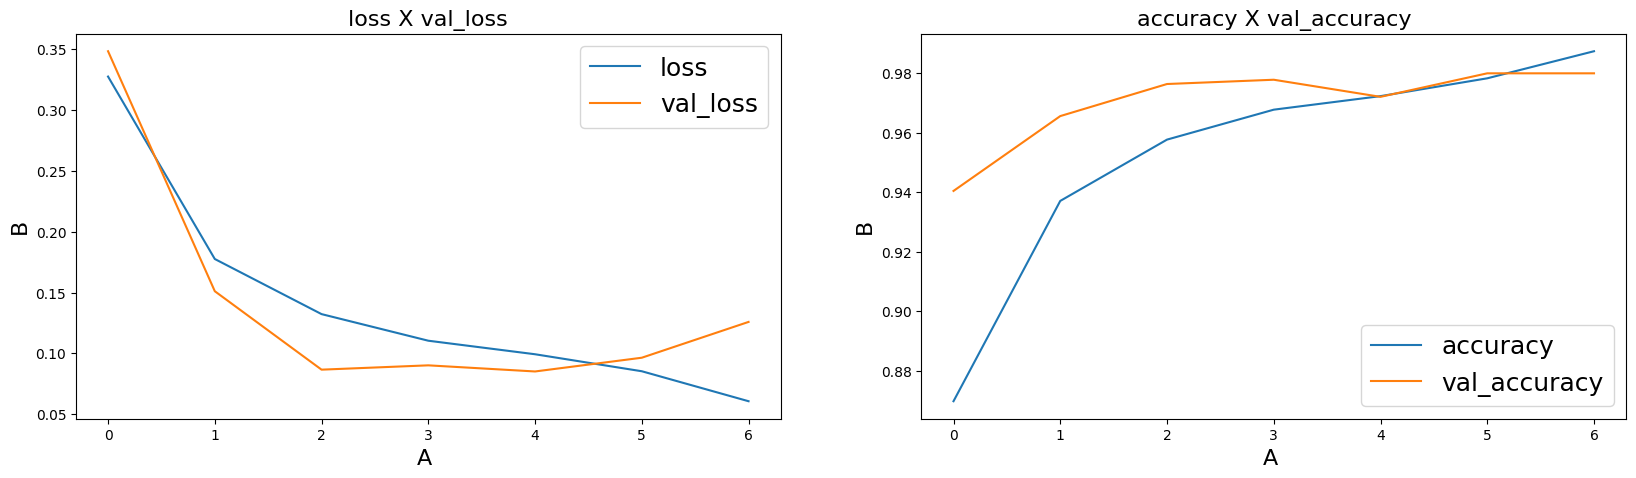

In [54]:
plot_learning_curves(history, [['loss', 'val_loss'],['accuracy', 'val_accuracy']])

In [55]:
y_preds = (model.predict(X_test) > 0.5).astype("int32")


44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step


In [56]:
!pip install -q transformers

In [57]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf

In [58]:
bert_texts = df['Message'].astype(str).tolist()
bert_labels = df['target_encoded'].tolist()

bert_x_train, bert_x_test, bert_y_train, bert_y_test = train_test_split(
    bert_texts, bert_labels, test_size=0.2, random_state=42, stratify=bert_labels
)
print(len(bert_x_train), len(bert_x_test))

4457 1115


In [59]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    bert_x_train,
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors="tf"
)
test_encodings = tokenizer(
    bert_x_test,
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors="tf"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [60]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    bert_y_train
)).shuffle(1000).batch(BATCH_SIZE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    bert_y_test
)).batch(BATCH_SIZE)

In [61]:
import tf_keras

bert_model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

optimizer = tf_keras.optimizers.Adam(learning_rate=2e-5)
loss = tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True)

bert_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
bert_model.summary()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_37 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109483778 (417.65 MB)
Trainable params: 109483778 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [62]:
bert_history = bert_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

Epoch 1/3
279/279 [==============================] - 130s 301ms/step - loss: 0.0800 - accuracy: 0.9758 - val_loss: 0.0462 - val_accuracy: 0.9830
Epoch 2/3
279/279 [==============================] - 77s 275ms/step - loss: 0.0229 - accuracy: 0.9930 - val_loss: 0.0210 - val_accuracy: 0.9937
Epoch 3/3
279/279 [==============================] - 76s 273ms/step - loss: 0.0040 - accuracy: 0.9984 - val_loss: 0.0420 - val_accuracy: 0.9919


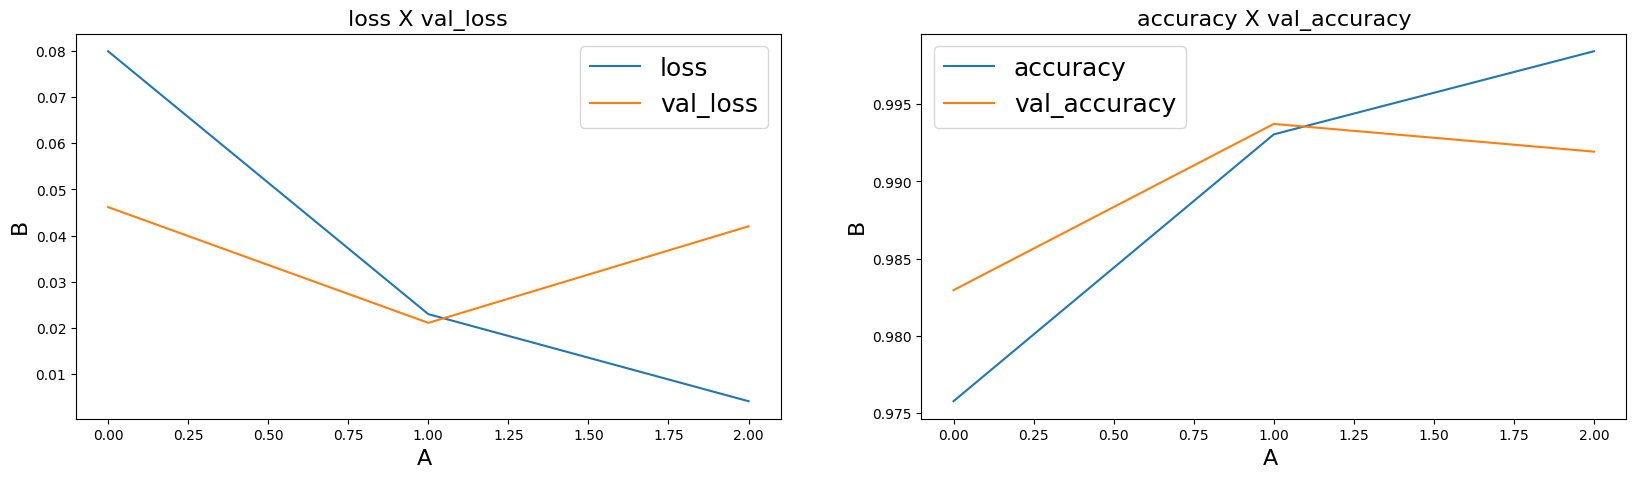

In [63]:
plot_learning_curves(bert_history, [['loss', 'val_loss'], ['accuracy', 'val_accuracy']])

In [64]:
bert_preds = bert_model.predict(test_dataset)
bert_pred_labels = np.argmax(bert_preds.logits, axis=1)

print(classification_report(bert_y_test, bert_pred_labels, target_names=le.classes_))
print(confusion_matrix(bert_y_test, bert_pred_labels))

70/70 [==============================] - 9s 86ms/step
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

[[964   2]
 [  7 142]]


In [65]:
bert_model.save_pretrained('bert_spam_model')
tokenizer.save_pretrained('bert_spam_model')

('bert_spam_model/tokenizer_config.json',
 'bert_spam_model/special_tokens_map.json',
 'bert_spam_model/vocab.txt',
 'bert_spam_model/added_tokens.json',
 'bert_spam_model/tokenizer.json')